## Тема
Проверка спецификации линейной регрессии: RESET-тест Рамсея. Исследовать ошибку I рода и мощность при пропуске нелинейности, взаимодействий и существенных регрессоров.

## Требования

Часть 2: моделирование (формат Jupyter Notebook (.ipynb) + сбилженный .html)
1. Исследование типа критерия (радикальный/консервативный/точный)
2. Мощность против альтернативы / разных альтернатив
3. Раскрытие вопроса реферата
4. Применение на реальных данных


Во всех темах свойства критерия исследуются на основе распределение p-values, полученного моделированием. Сравнение тестов идет по ошибкам первого и второго рода/мощности. При сравнении по мощности, всегда сначала проверьте применимость критерия (что вероятность ошибки первого рода примерно равна уровню значимости). Если критерий радикальный, его нельзя использовать и бессмысленно сравнивать по мощности.


In [4]:
import random
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
import scipy.stats as stats
import seaborn as sns
import itertools

# Функции для проведения симуляций и исследования результатов

In [186]:
def compute_error_rate(trials):
    """Декоратор для расчета доли ошибок в заданном количестве испытаний
    Работает с любым типом ошибки
    """
    def decorator(single_trial_func):
        def wrapper(*args, alpha=0.05, error_type='1', **kwargs):
            error_map = {
                '1': lambda p: p < alpha,
                '2': lambda p: p >= alpha
            }
            error_func = error_map[error_type]
            errors = 0
            p_values = []

            for i in range(trials):
                is_error, p_value = single_trial_func(*args, error_func=error_func, **kwargs)
                errors += int(is_error)
                p_values.append(p_value)

            return errors / trials, p_values
        return wrapper
    return decorator


@compute_error_rate(trials=300)
def single_reset_test(sample_size, true_non_linear_terms_amount,
                     feature_amount, added_features,
                      interactions, sig_regr_corr, sig_regr_effect, error_func
                      ):
    x, w, b, y = generate_data(sample_size, true_non_linear_terms_amount, feature_amount, interactions, sig_regr_corr, sig_regr_effect)
    ss1, ss2, df1, df2 = compare_lin_regs(x, w, b, y, added_features)

    p = compute_f_significance(ss1, ss2, df1, df2)

    return error_func(p), p

# функция для расчета уровня значимости F-статистики
def compute_f_significance(ss1, ss2, df1, df2):
  dfd = df1 - df2
  f_value = ((ss1 - ss2)/ss2) / ((dfd)/(df2))
  p_value = stats.f.sf(f_value, dfd, df2) # считаем вероятность получить более экстремальные значения справа

  return p_value.item()

# функция для расчета параметров двух линейных регрессий
def compare_lin_regs(x, w, b, y, added_features_amount=3):
  base_lin_reg = LinearRegression(fit_intercept=True)
  new_lin_reg = LinearRegression(fit_intercept=True)

  base_lin_reg.fit(x, y)
  y_hat = base_lin_reg.predict(x)

  new_x = np.hstack([x] + [y_hat ** i for i in range(2, 2 + added_features_amount)])

  new_lin_reg.fit(new_x, y)
  y_hat_adv = new_lin_reg.predict(new_x)

  ss1 = np.sum((y-y_hat)**2)
  ss2 = np.sum((y-y_hat_adv)**2)

  df1 = x.shape[0] - x.shape[1] - 1
  df2 = new_x.shape[0] - new_x.shape[1] - 1

  return ss1, ss2, df1, df2

# функция для генерации случайных данных для обучения линейной регрессии
def generate_data(sample_size=100, true_non_linear_terms=2, feature_amount=3, interactions=1, sig_regr_corr=0.8, sig_regr_effect=3):

  X = np.random.uniform(-5, 5, (sample_size, feature_amount))
  w = np.random.uniform(-5, 5, (feature_amount, 1))
  b = np.random.uniform(-5, 5)
  e = np.random.normal(0, 1, (sample_size,1))

  # задаем существенный регрессор с заданной корреляцией
  Z = np.random.normal(0, 1, (sample_size, 1))
  E = np.random.normal(0, 1, (sample_size, 1))

  X_hidden = sig_regr_corr * Z + np.sqrt(1 - sig_regr_corr**2) * E
  X[:, 0] = X_hidden.flatten()

  base_y = X @ w + b + e + sig_regr_effect * Z

  # задаем существенные взаимодействия
  if interactions > 0:
        all_pairs = list(itertools.combinations(range(feature_amount), 2))

        actual_interactions = min(interactions, len(all_pairs))
        pairs = random.sample(all_pairs, actual_interactions)

        for i, j in pairs:
            interaction_weight = np.random.uniform(-3, 3)
            base_y += interaction_weight * (X[:, i] * X[:, j]).reshape(-1, 1)


  # добавляем нелинейность
  if true_non_linear_terms > 0:
    standardized_y = (base_y - base_y.mean()) / base_y.std()
    base_y += np.sum([np.random.uniform(-2, 2) * standardized_y ** i for i in range(2, 2 + true_non_linear_terms)], axis=0)



  # возвращаем данные так, чтобы модель не знала ни про существенные регрессоры, ни про взаимодействия, ни про нелинейности
  return X, w, b, base_y


def plot_errors_distribution(errors_df, error_type='1'):
    sns.set_theme(style="whitegrid")

    plt.figure(figsize=(10, 6), dpi=100)

    ax = sns.histplot(
      errors_df['Доля ошибок'],
      bins=15,
      kde=True,
      color='#e67e22',
      edgecolor='white',
      line_kws={'linewidth': 3}
    )

    plt.axvline(errors_df['Доля ошибок'].mean(), label=f'Среднее: {np.round(errors_df["Доля ошибок"].mean(),4)}')

    plt.title(f"Распределение ошибок {error_type} рода", fontsize=18, pad=20, fontweight='bold')
    plt.xlabel("Доля ошибок", fontsize=14)
    plt.ylabel("Частота", fontsize=14)
    plt.legend()

    sns.despine()

    plt.show()


def plot_decision_tree_thresholds(errors_df, error_type='1'):
    tree = DecisionTreeRegressor(max_depth=3)
    X, y = errors_df.drop(columns=['Доля ошибок', 'Тип ошибки']), errors_df['Доля ошибок']
    tree.fit(X, y)

    plt.figure(figsize=(20, 10), dpi=100)

    feature_names = ['Размер выборки', 'Количество реальных линейных предикторов',
       'Количество шумовых нелинейных предикторов',
       'Количество реальных нелинейных предикторов',
       'Количество взаимодействий', 'Корреляция существенного регрессора',
       'Влияние существенного регрессора', 'Тип ошибки', 'Доля ошибок']

    plot_tree(
        tree,
        feature_names=feature_names,
        filled=True,
        rounded=True,
        fontsize=12,
        impurity=False
    )

    plt.title(f"Комбинации параметров, влияющие на долю ошибок {error_type} рода", fontsize=18)
    plt.show()


Чтобы создать новую переменную $X$, которая будет иметь заданную корреляцию $\rho$ (от -1 до 1) с уже существующей переменной $Z$, тебе нужно «смешать» $Z$ с абсолютно новым независимым шумом.

Пусть $Z$ — твоя текущая переменная (желательно стандартизованная, со средним 0 и дисперсией 1), а $E$ — новый, свежесгенерированный вектор из стандартного нормального распределения.

Формула смешивания (на основе разложения Холецкого для двух переменных) выглядит так:

$$X = \rho \cdot Z + \sqrt{1 - \rho^2} \cdot E$$

In [187]:
def run_reset_test_simulation(iterations, sample_sizes, true_non_linear_terms_amounts,
                              feature_amounts, added_features_amounts, interactions,
                              sig_regr_correlations, sig_regr_effects):
  simulations_errors_map = {}
  simulation_num = 0

  for sample_size in sample_sizes:
    for feature_amount in feature_amounts:
      for added_features_amount in added_features_amounts:
        for true_non_linear_terms_amount in true_non_linear_terms_amounts:
          for sig_regr_corr in sig_regr_correlations:
            for sig_regr_effect in sig_regr_effects:
              for interaction in interactions:
                  simulation_num += 1

                  ovb = (sig_regr_corr != 0 and sig_regr_effect != 0)
                  is_non_linear = (true_non_linear_terms_amount == 0 and interaction == 0 and not ovb)

                  error_type = '1' if is_non_linear else '2'
                  errors_rate, p_values = single_reset_test(sample_size, true_non_linear_terms_amount, feature_amount,
                                                  added_features_amount, interaction, sig_regr_corr,
                                                  sig_regr_effect, error_type=error_type)

                  simulations_errors_map[simulation_num] = {
                      'Номер симуляции': simulation_num,
                      'Размер выборки': sample_size,
                      'Количество реальных линейных предикторов': feature_amount,
                      'Количество шумовых нелинейных предикторов': added_features_amount,
                      'Количество реальных нелинейных предикторов': true_non_linear_terms_amount,
                      'Количество взаимодействий': interaction,
                      'Корреляция существенного регрессора': sig_regr_corr,
                      'Влияние существенного регрессора': sig_regr_effect,
                      'Тип ошибки': error_type,
                      'Доля ошибок': errors_rate,
                      'p-values': p_values
                  }

                  print('-'*100)
                  print(f'Симуляция №{simulation_num}')
                  print(f'Размер выборки: {sample_size}')
                  print(f'Количество реальных нелинейных предикторов: {true_non_linear_terms_amount}')
                  print(f'Количество реальных линейных предикторов: {feature_amount}')
                  print(f'Количество шумовых нелинейных предикторов: {added_features_amount}')
                  print(f'Количество взаимодействий: {interaction}')
                  print(f'Корреляция существенного регрессора: {sig_regr_corr}')
                  print(f'Влияние существенного регрессора: {sig_regr_effect}')
                  print(f'Тип ошибки: {error_type}')
                  print(f'Доля ошибок: {errors_rate}')

  return simulations_errors_map

# Исследование ошибки 1 рода

In [188]:
# Пробегаем симуляции с отсутствием любых искажений (нелинейных связей, взамодействий, существенных регрессоров)

sample_sizes = [100, 250, 500, 1000, 2000]
true_non_linear_terms_amounts = [0]
feature_amounts = [1, 2, 5, 10, 20]
added_features_amounts = [1, 2, 3, 4]
significant_regressor_correlations = [0]
significant_regressor_effects = [0]
interactions = [0]

first_type_errors_map = run_reset_test_simulation(1000, sample_sizes, true_non_linear_terms_amounts,
                                                  feature_amounts, added_features_amounts, interactions,
                                                  significant_regressor_correlations, significant_regressor_effects)

----------------------------------------------------------------------------------------------------
Симуляция №1
Размер выборки: 100
Количество реальных нелинейных предикторов: 0
Количество реальных линейных предикторов: 1
Количество шумовых нелинейных предикторов: 1
Количество взаимодействий: 0
Корреляция существенного регрессора: 0
Влияние существенного регрессора: 0
Тип ошибки: 1
Доля ошибок: 0.04666666666666667
----------------------------------------------------------------------------------------------------
Симуляция №2
Размер выборки: 100
Количество реальных нелинейных предикторов: 0
Количество реальных линейных предикторов: 1
Количество шумовых нелинейных предикторов: 2
Количество взаимодействий: 0
Корреляция существенного регрессора: 0
Влияние существенного регрессора: 0
Тип ошибки: 1
Доля ошибок: 0.043333333333333335
----------------------------------------------------------------------------------------------------
Симуляция №3
Размер выборки: 100
Количество реальных нелин

In [189]:
type_one_error_df = pd.DataFrame.from_dict(first_type_errors_map, orient='index').set_index('Номер симуляции')

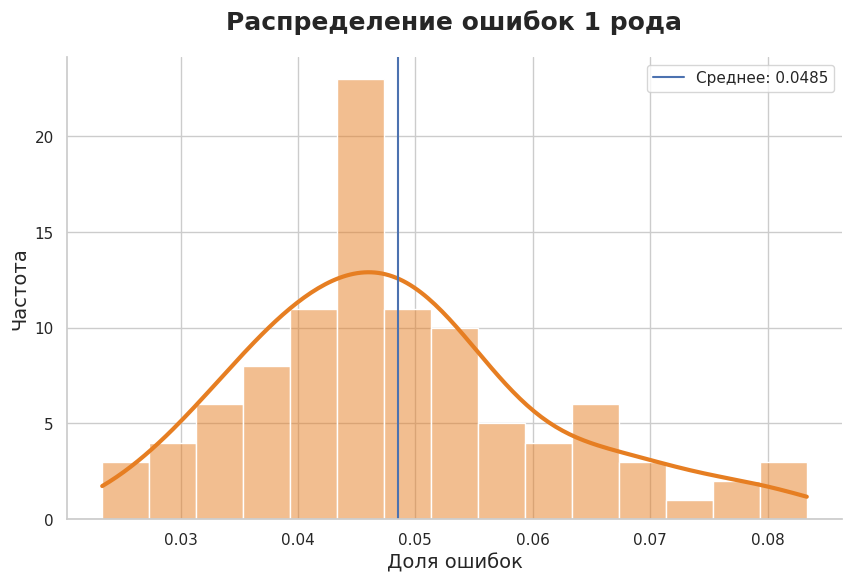

In [190]:
plot_errors_distribution(type_one_error_df, error_type='1')

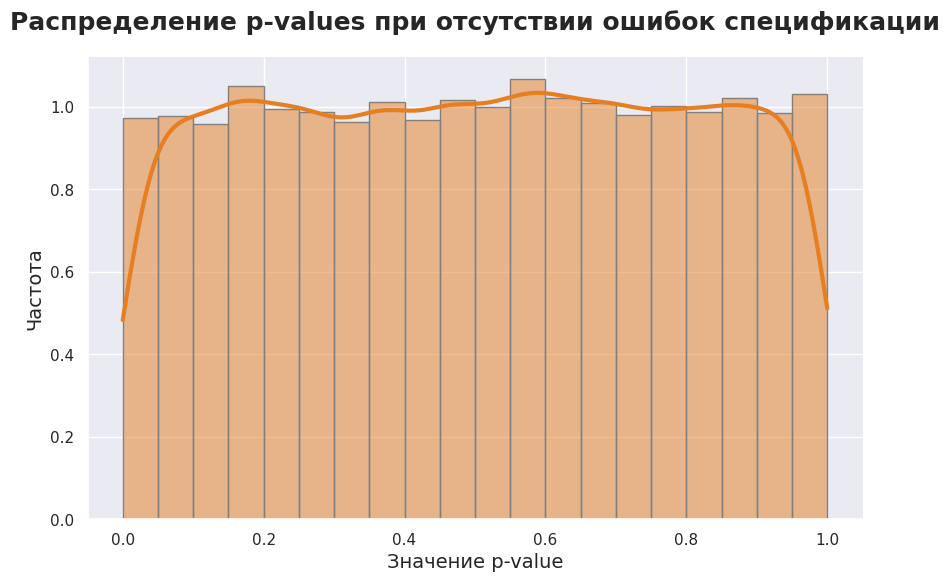

In [202]:
sns.set_theme(style="darkgrid")

plt.figure(figsize=(10, 6), dpi=100)

ax = sns.histplot(
  type_one_error_df.explode('p-values')['p-values'].astype(float),
  bins=20,
  stat='density',
  kde=True,
  color='#e67e22',
  edgecolor='gray',
  line_kws={'linewidth': 3}
)

plt.title(f"Распределение p-values при отсутствии ошибок спецификации", fontsize=18, pad=20, fontweight='bold')
plt.xlabel("Значение p-value", fontsize=14)
plt.ylabel("Частота", fontsize=14)

sns.despine()

plt.show()

In [197]:
columns_to_drop = ['Тип ошибки','p-values', 'Количество взаимодействий', 'Корреляция существенного регрессора', 'Влияние существенного регрессора', 'Количество реальных нелинейных предикторов']
corr = type_one_error_df.drop(columns=columns_to_drop).corr().apply(lambda x: np.round(x, 4))

Корреляций между долей ошибок 1 рода и параметрами симуляции практически нет

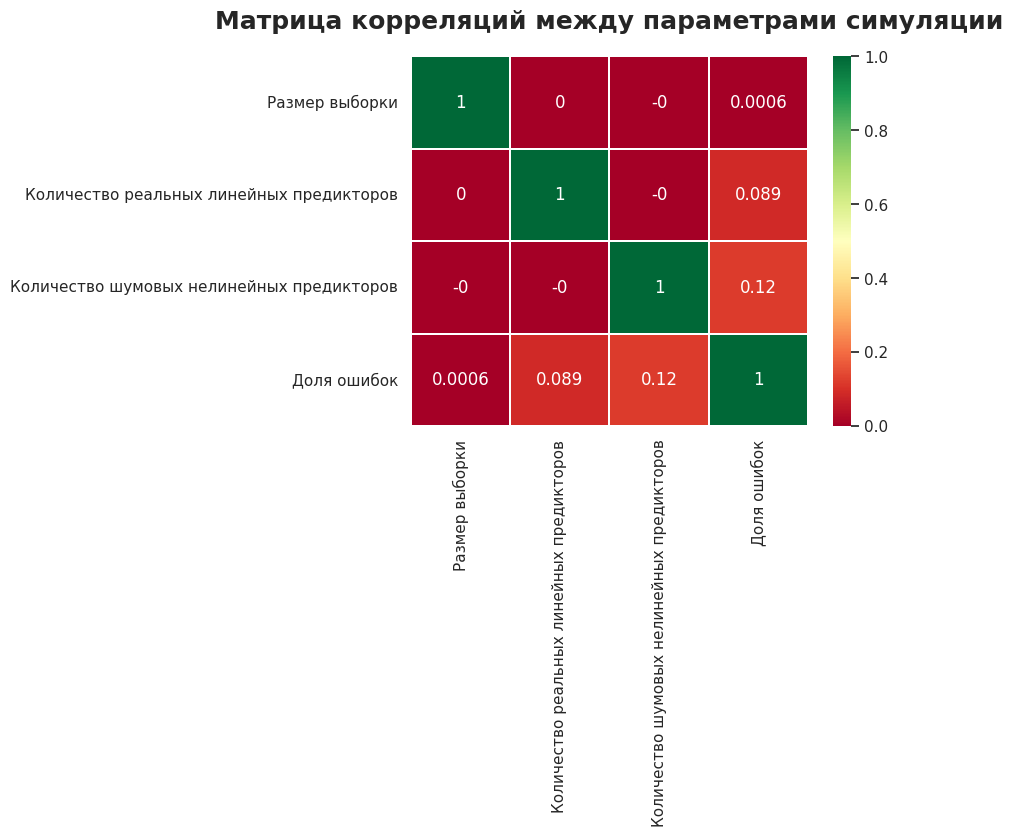

In [204]:
sns.heatmap(corr, cmap ='RdYlGn', linewidths = 0.30, annot = True)
plt.title(f"Матрица корреляций между параметрами симуляции", fontsize=18, pad=20, fontweight='bold')
plt.show()

Комбинация маленькой выборки, большого числа реальных предикторов и большого количества шумовых нелинейных предикторов увеличивает долю ошибок 1 рода.

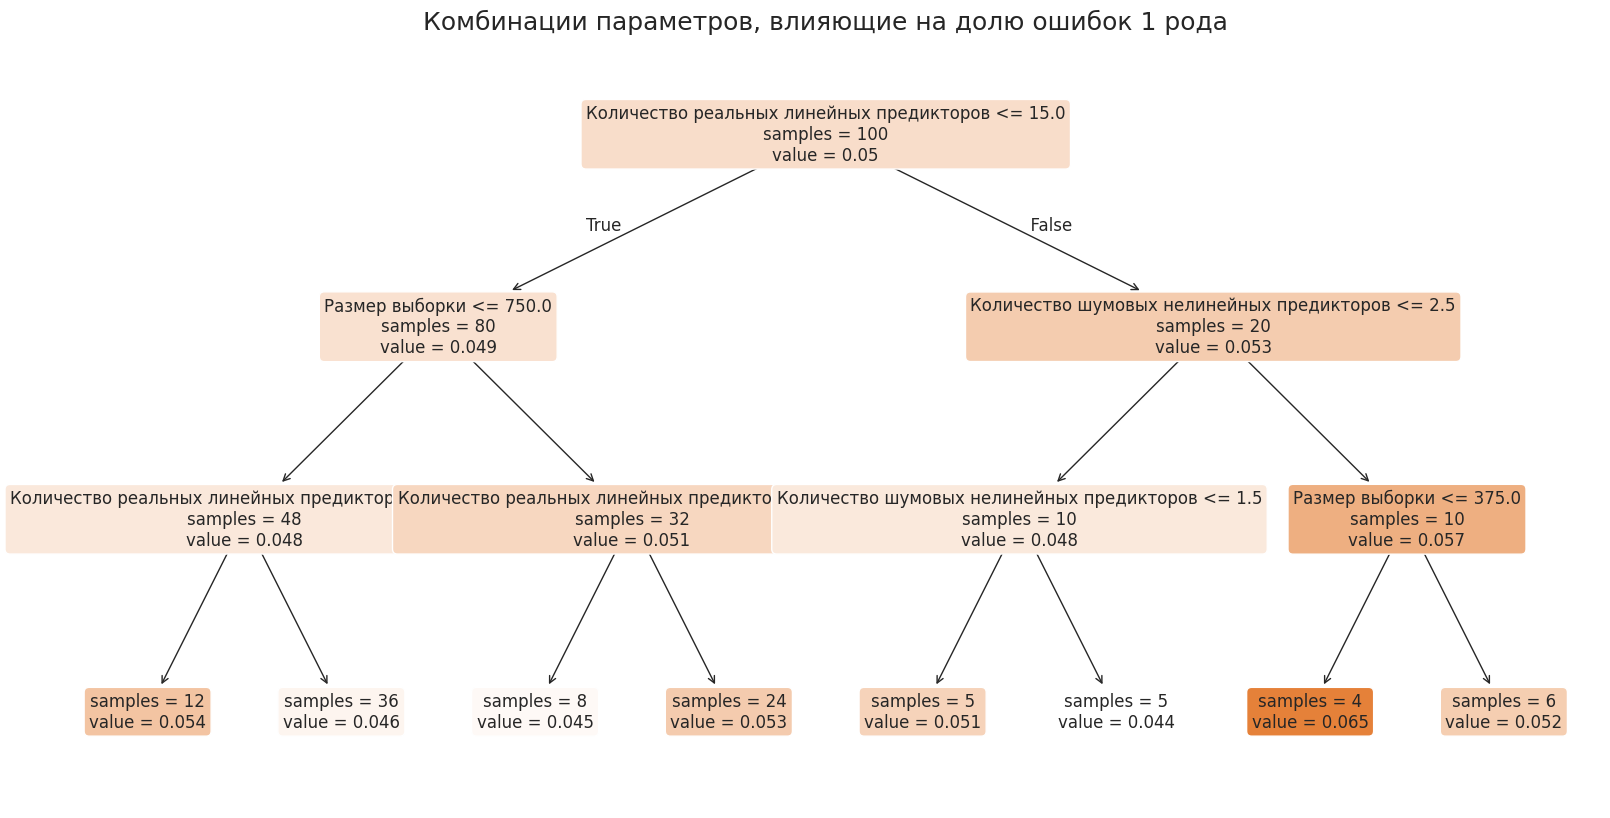

In [143]:
plot_decision_tree_thresholds(type_one_error_df, error_type='1')

In [144]:
type_one_error_df.to_csv('type_one_error_df.csv')

#### **Вывод**

RESET-тест в реальных симуляциях показал свойства точного критерия, имеющего вероятность совершения ошибок 1 рода примерно равную заданному уровню значимости. Распределение p-values равномерное.

# Исследование ошибки 2 рода

### При наличии нелинейных предикторов

In [152]:
# Пробегаем симуляции только с нелинейными предикторами

sample_sizes = [100, 250, 500, 1000]
true_non_linear_terms_amounts = [1, 2, 3, 4]
feature_amounts = [1, 2, 5, 10]
added_features_amounts = [1, 2, 3, 4]
significant_regressor_correlations = [0]
significant_regressor_effects = [0]
interactions = [0]

second_type_errors_map_non_linear_terms = run_reset_test_simulation(1000, sample_sizes, true_non_linear_terms_amounts,
                                                  feature_amounts, added_features_amounts, interactions,
                                                  significant_regressor_correlations, significant_regressor_effects)

----------------------------------------------------------------------------------------------------
Симуляция №1
Размер выборки: 100
Количество реальных нелинейных предикторов: 1
Количество реальных линейных предикторов: 1
Количество шумовых нелинейных предикторов: 1
Количество взаимодействий: 0
Корреляция существенного регрессора: 0
Влияние существенного регрессора: 0
Тип ошибки: 2
Доля ошибок: 0.19666666666666666
----------------------------------------------------------------------------------------------------
Симуляция №2
Размер выборки: 100
Количество реальных нелинейных предикторов: 2
Количество реальных линейных предикторов: 1
Количество шумовых нелинейных предикторов: 1
Количество взаимодействий: 0
Корреляция существенного регрессора: 0
Влияние существенного регрессора: 0
Тип ошибки: 2
Доля ошибок: 0.30666666666666664
----------------------------------------------------------------------------------------------------
Симуляция №3
Размер выборки: 100
Количество реальных нелине

In [153]:
type_two_error_non_linear_terms_df = pd.DataFrame.from_dict(second_type_errors_map_non_linear_terms, orient='index').set_index('Номер симуляции')

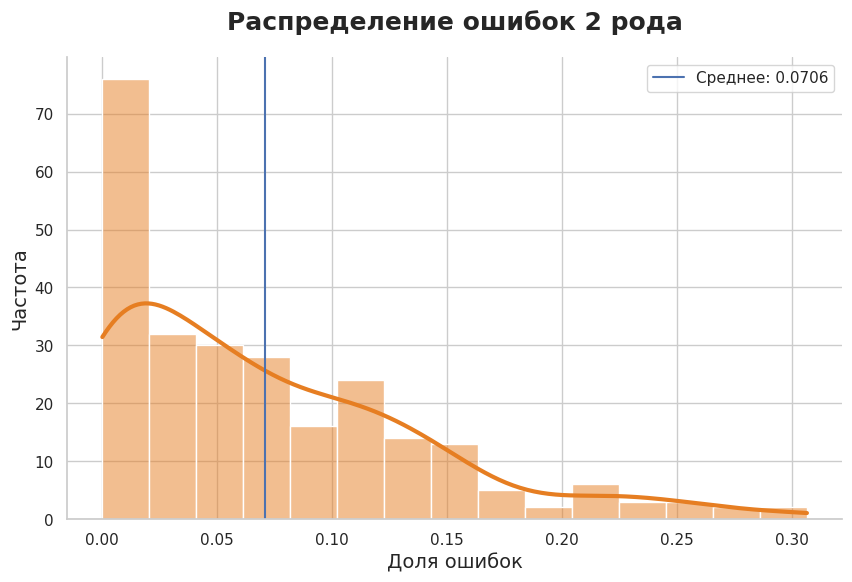

In [154]:
plot_errors_distribution(type_two_error_non_linear_terms_df, error_type='2')

In [206]:
columns_to_drop = ['Тип ошибки','p-values', 'Количество взаимодействий', 'Корреляция существенного регрессора', 'Влияние существенного регрессора']

corr = type_two_error_non_linear_terms_df.drop(columns=columns_to_drop).corr().apply(lambda x: np.round(x, 4))

KeyError: "['p-values'] not found in axis"

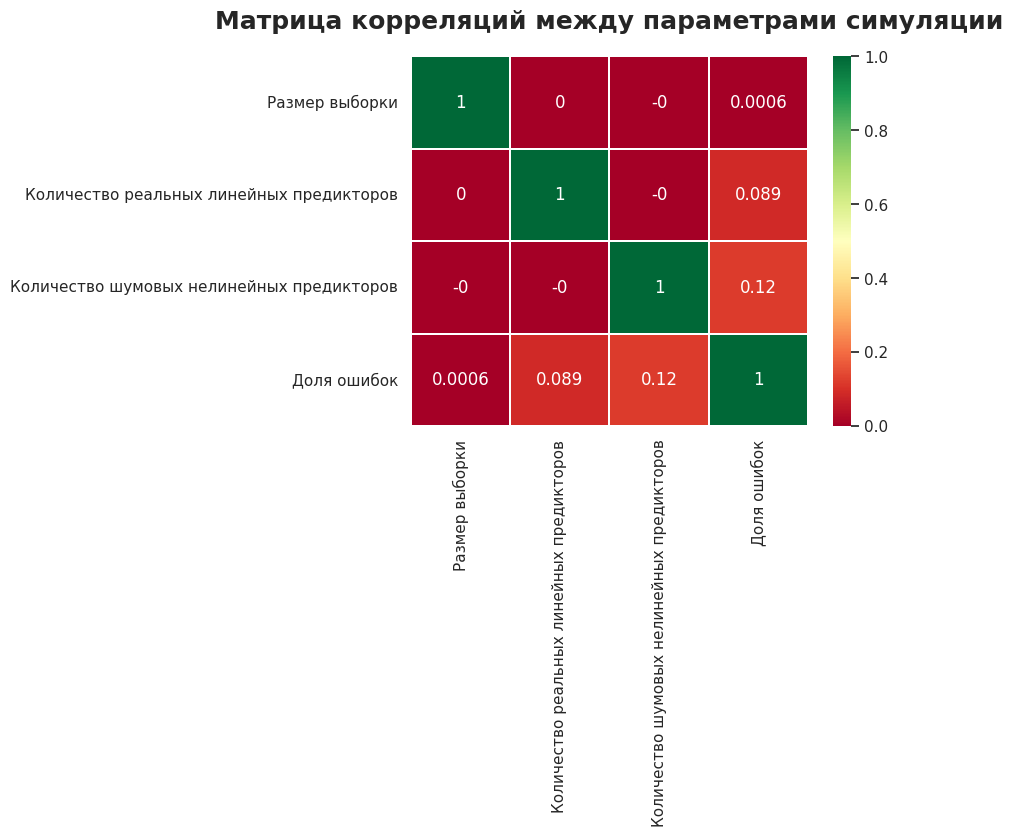

In [205]:
plt.title(f"Матрица корреляций между параметрами симуляции", fontsize=18, pad=20, fontweight='bold')

sns.heatmap(corr, cmap ='RdYlGn', linewidths = 0.30, annot = True)
plt.show()

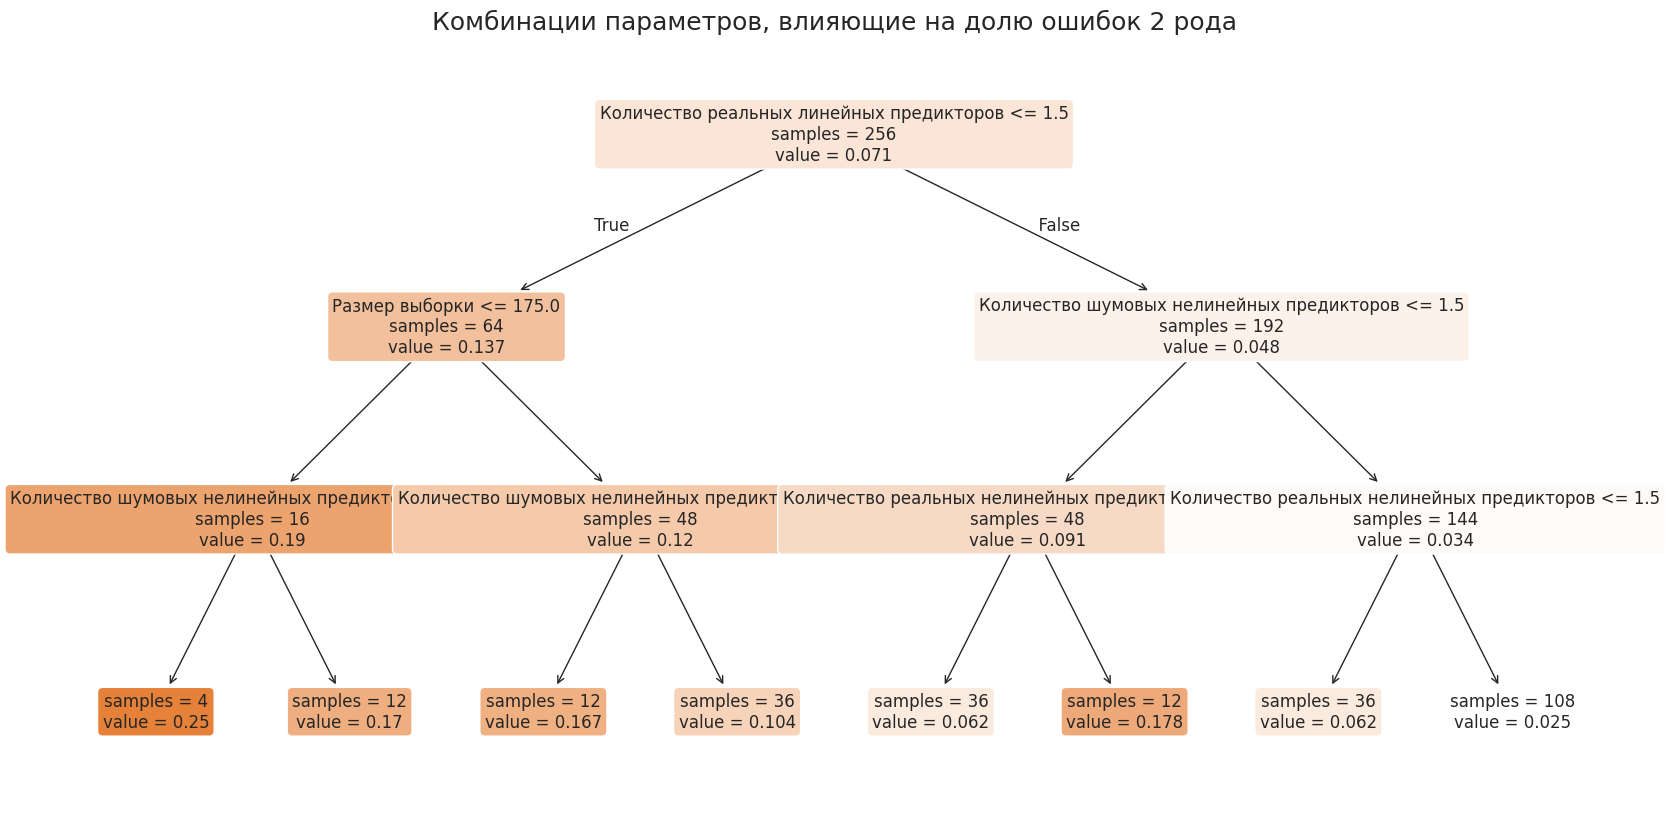

In [157]:
plot_decision_tree_thresholds(type_two_error_non_linear_terms_df, error_type='2')

In [158]:
type_two_error_non_linear_terms_df.to_csv('type_two_error_non_linear_terms_df.csv')

#### **Вывод**

Симуляции с ошибкой спецификации при наличии нелинейности также показали, что RESET-тест имеет свойства консервативного критерия - он продемонстрировал сниженную мощность, примерно 0.75

### При наличии взаимодействий

In [159]:
# Пробегаем симуляции только с взаимодействиями

sample_sizes = [100, 250, 500, 1000]
true_non_linear_terms_amounts = [0]
feature_amounts = [3, 4, 5, 10]
added_features_amounts = [1, 2, 3, 4]
significant_regressor_correlations = [0]
significant_regressor_effects = [0]
interactions = [1, 2, 3]

second_type_errors_map_interactions = run_reset_test_simulation(1000, sample_sizes, true_non_linear_terms_amounts,
                                                  feature_amounts, added_features_amounts, interactions,
                                                  significant_regressor_correlations, significant_regressor_effects)

----------------------------------------------------------------------------------------------------
Симуляция №1
Размер выборки: 100
Количество реальных нелинейных предикторов: 0
Количество реальных линейных предикторов: 3
Количество шумовых нелинейных предикторов: 1
Количество взаимодействий: 1
Корреляция существенного регрессора: 0
Влияние существенного регрессора: 0
Тип ошибки: 2
Доля ошибок: 0.4
----------------------------------------------------------------------------------------------------
Симуляция №2
Размер выборки: 100
Количество реальных нелинейных предикторов: 0
Количество реальных линейных предикторов: 3
Количество шумовых нелинейных предикторов: 1
Количество взаимодействий: 2
Корреляция существенного регрессора: 0
Влияние существенного регрессора: 0
Тип ошибки: 2
Доля ошибок: 0.27
----------------------------------------------------------------------------------------------------
Симуляция №3
Размер выборки: 100
Количество реальных нелинейных предикторов: 0
Количество 

In [160]:
type_two_error_interactions_df = pd.DataFrame.from_dict(second_type_errors_map_interactions, orient='index').set_index('Номер симуляции')

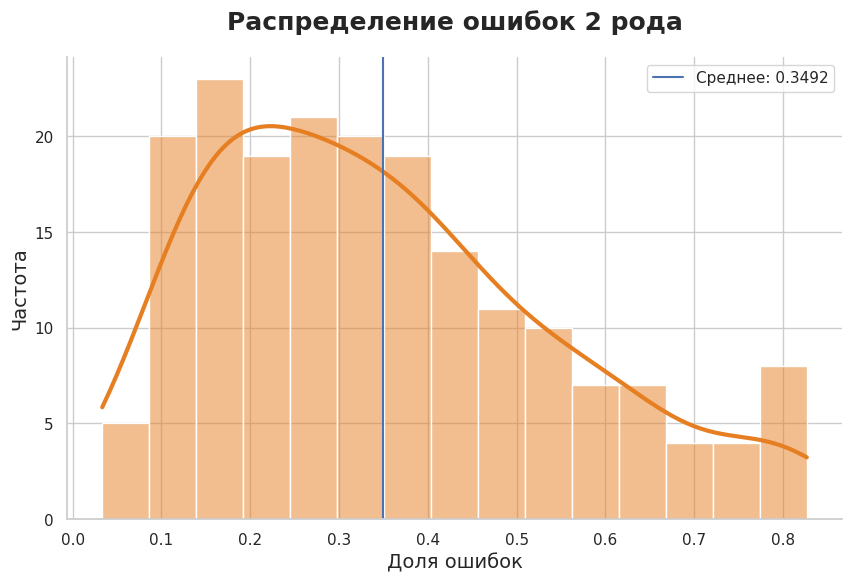

In [161]:
plot_errors_distribution(type_two_error_interactions_df, error_type='2')

In [162]:
columns_to_drop = ['Тип ошибки', 'p-values', 'Количество реальных нелинейных предикторов', 'Корреляция существенного регрессора', 'Влияние существенного регрессора']

corr = type_two_error_interactions_df.drop(columns=columns_to_drop).corr().apply(lambda x: np.round(x, 4))

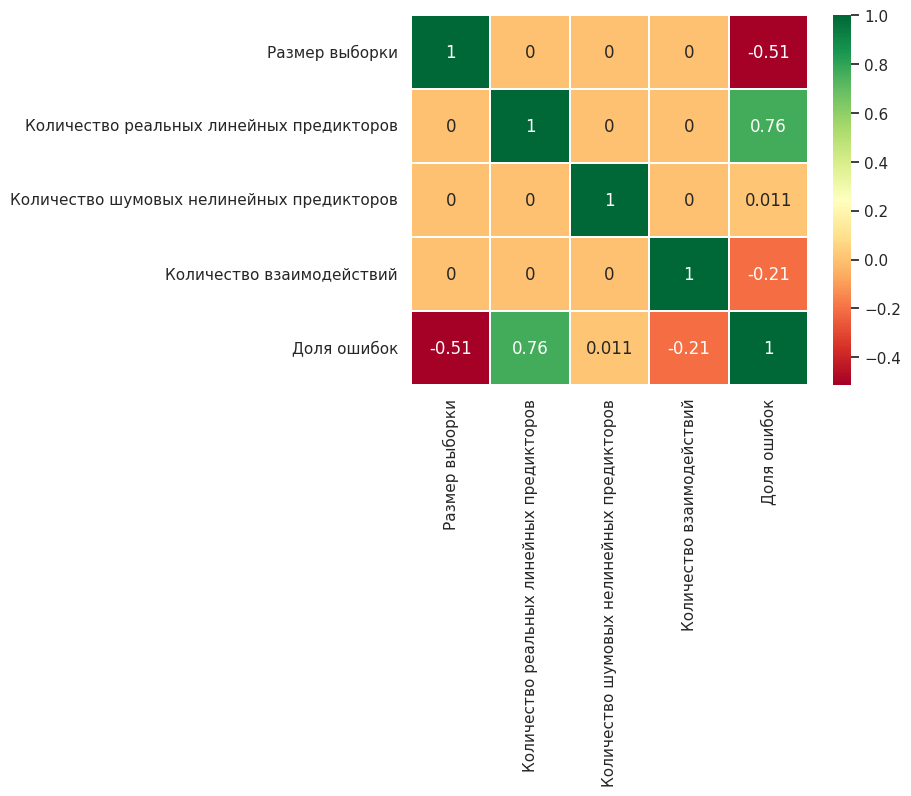

In [163]:
plt.title(f"Матрица корреляций между параметрами симуляции", fontsize=18, pad=20, fontweight='bold')

sns.heatmap(corr, cmap ='RdYlGn', linewidths = 0.30, annot = True)
plt.show()

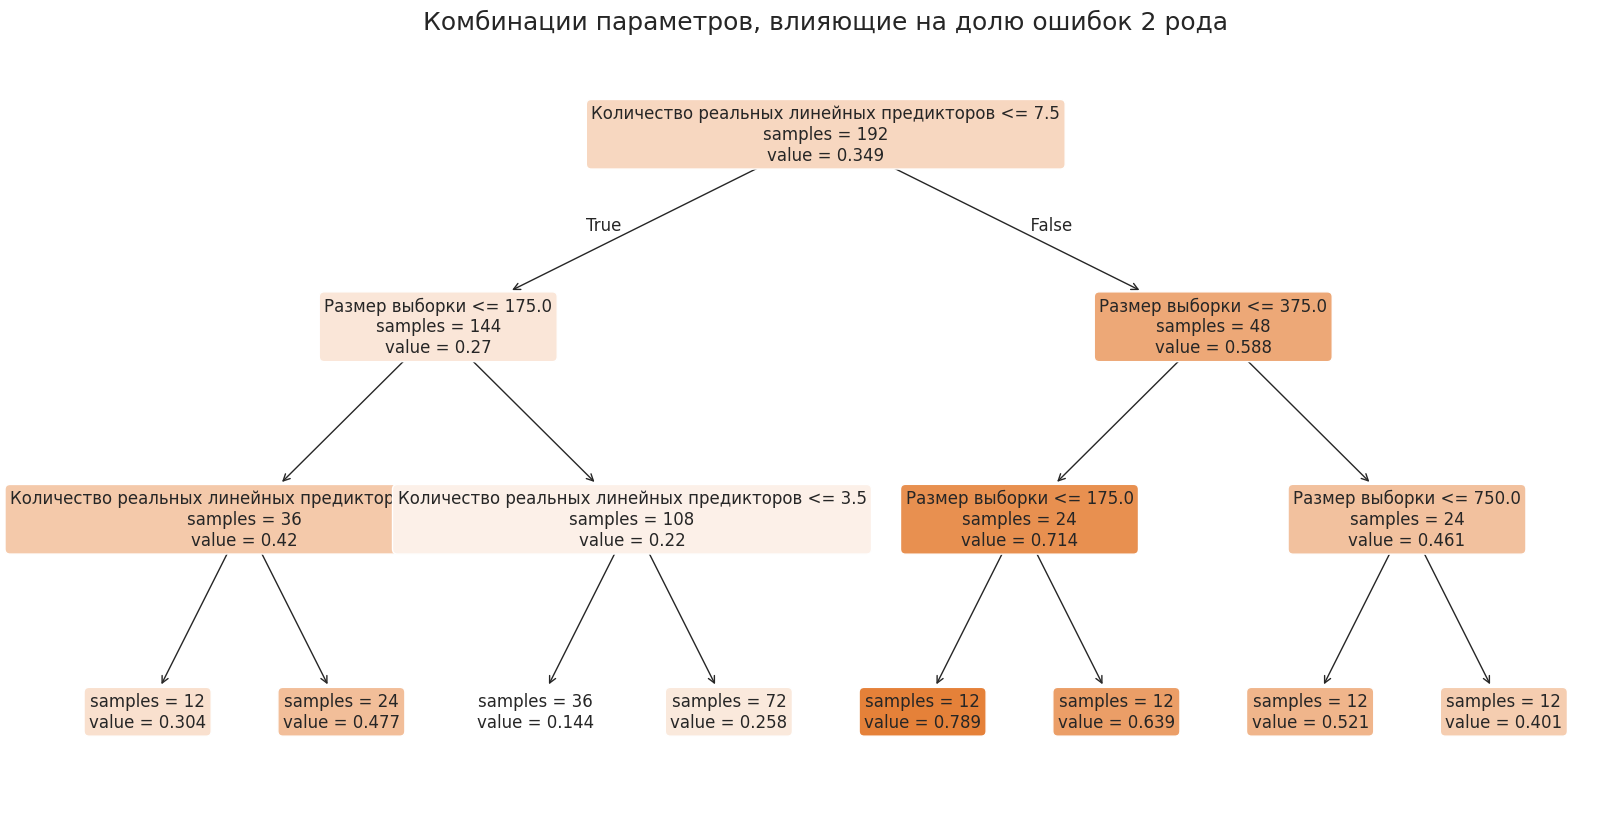

In [164]:
plot_decision_tree_thresholds(type_two_error_interactions_df, error_type='2')

In [165]:
type_two_error_interactions_df.to_csv('type_two_error_interactions_df.csv')

### При наличии существенных регрессоров

In [166]:
# Пробегаем симуляции только с значительными регрессорами

sample_sizes = [100, 500, 1000]
true_non_linear_terms_amounts = [0]
feature_amounts = [3, 4, 5, 10]
added_features_amounts = [1, 2, 3, 4]
significant_regressor_correlations = [0.05, 0.5, 0.9]
significant_regressor_effects = [1, 2, 5]
interactions = [0]

second_type_errors_sig_regr = run_reset_test_simulation(1000, sample_sizes, true_non_linear_terms_amounts,
                                                  feature_amounts, added_features_amounts, interactions,
                                                  significant_regressor_correlations, significant_regressor_effects)

----------------------------------------------------------------------------------------------------
Симуляция №1
Размер выборки: 100
Количество реальных нелинейных предикторов: 0
Количество реальных линейных предикторов: 3
Количество шумовых нелинейных предикторов: 1
Количество взаимодействий: 0
Корреляция существенного регрессора: 0.05
Влияние существенного регрессора: 1
Тип ошибки: 2
Доля ошибок: 0.96
----------------------------------------------------------------------------------------------------
Симуляция №2
Размер выборки: 100
Количество реальных нелинейных предикторов: 0
Количество реальных линейных предикторов: 3
Количество шумовых нелинейных предикторов: 1
Количество взаимодействий: 0
Корреляция существенного регрессора: 0.05
Влияние существенного регрессора: 2
Тип ошибки: 2
Доля ошибок: 0.9266666666666666
----------------------------------------------------------------------------------------------------
Симуляция №3
Размер выборки: 100
Количество реальных нелинейных преди

In [167]:
type_two_error_sig_regr_df = pd.DataFrame.from_dict(second_type_errors_sig_regr, orient='index').set_index('Номер симуляции')

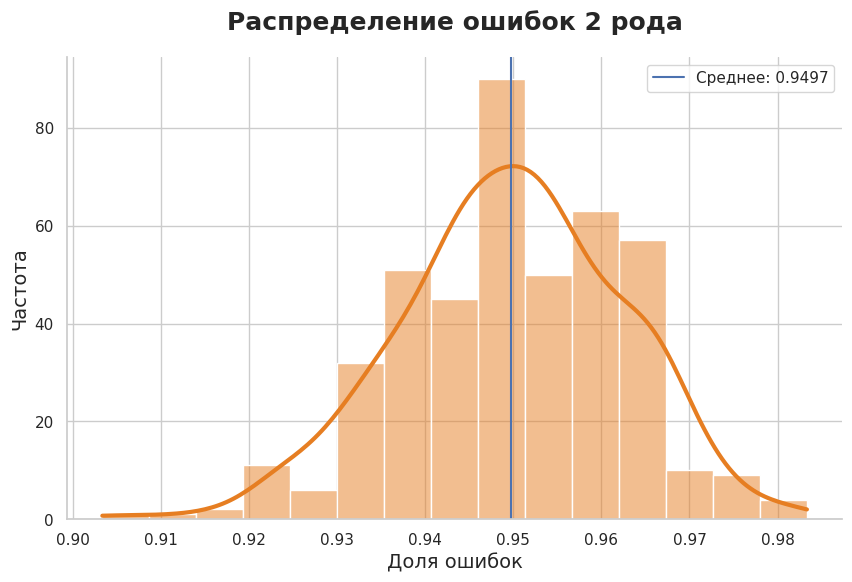

In [168]:
plot_errors_distribution(type_two_error_sig_regr_df, error_type='2')

In [169]:
plt.title(f"Матрица корреляций между параметрами симуляции", fontsize=18, pad=20, fontweight='bold')

columns_to_drop = ['Тип ошибки', 'p-values', 'Количество реальных нелинейных предикторов', 'Количество взаимодействий']

corr = type_two_error_sig_regr_df.drop(columns=columns_to_drop).corr().apply(lambda x: np.round(x, 4))

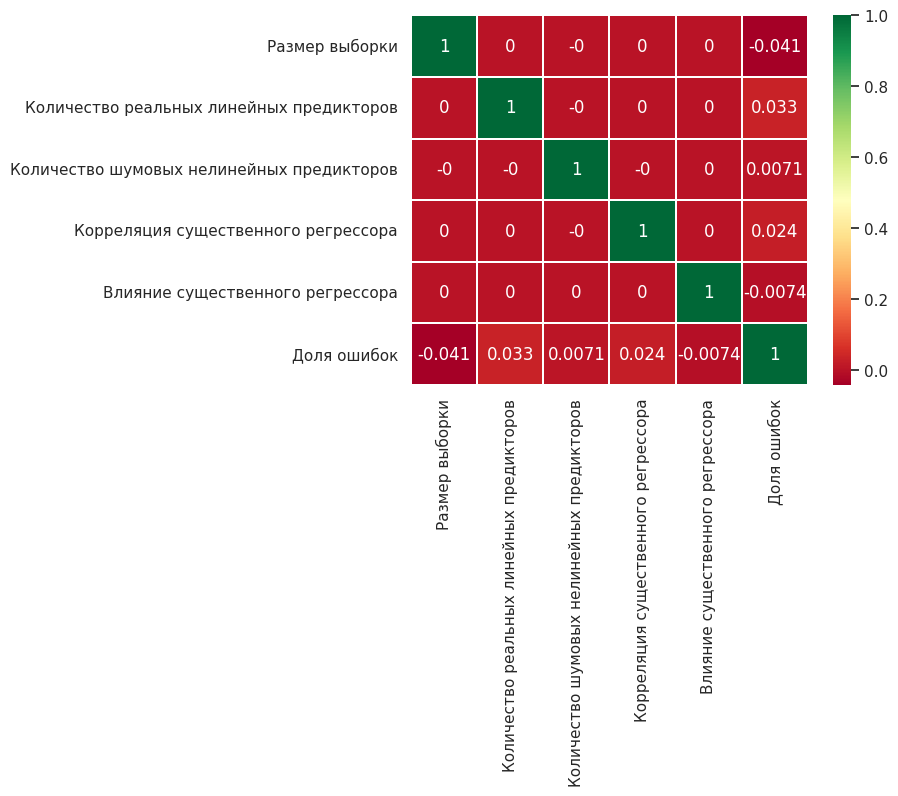

In [170]:
sns.heatmap(corr, cmap ='RdYlGn', linewidths = 0.30, annot = True)
plt.show()

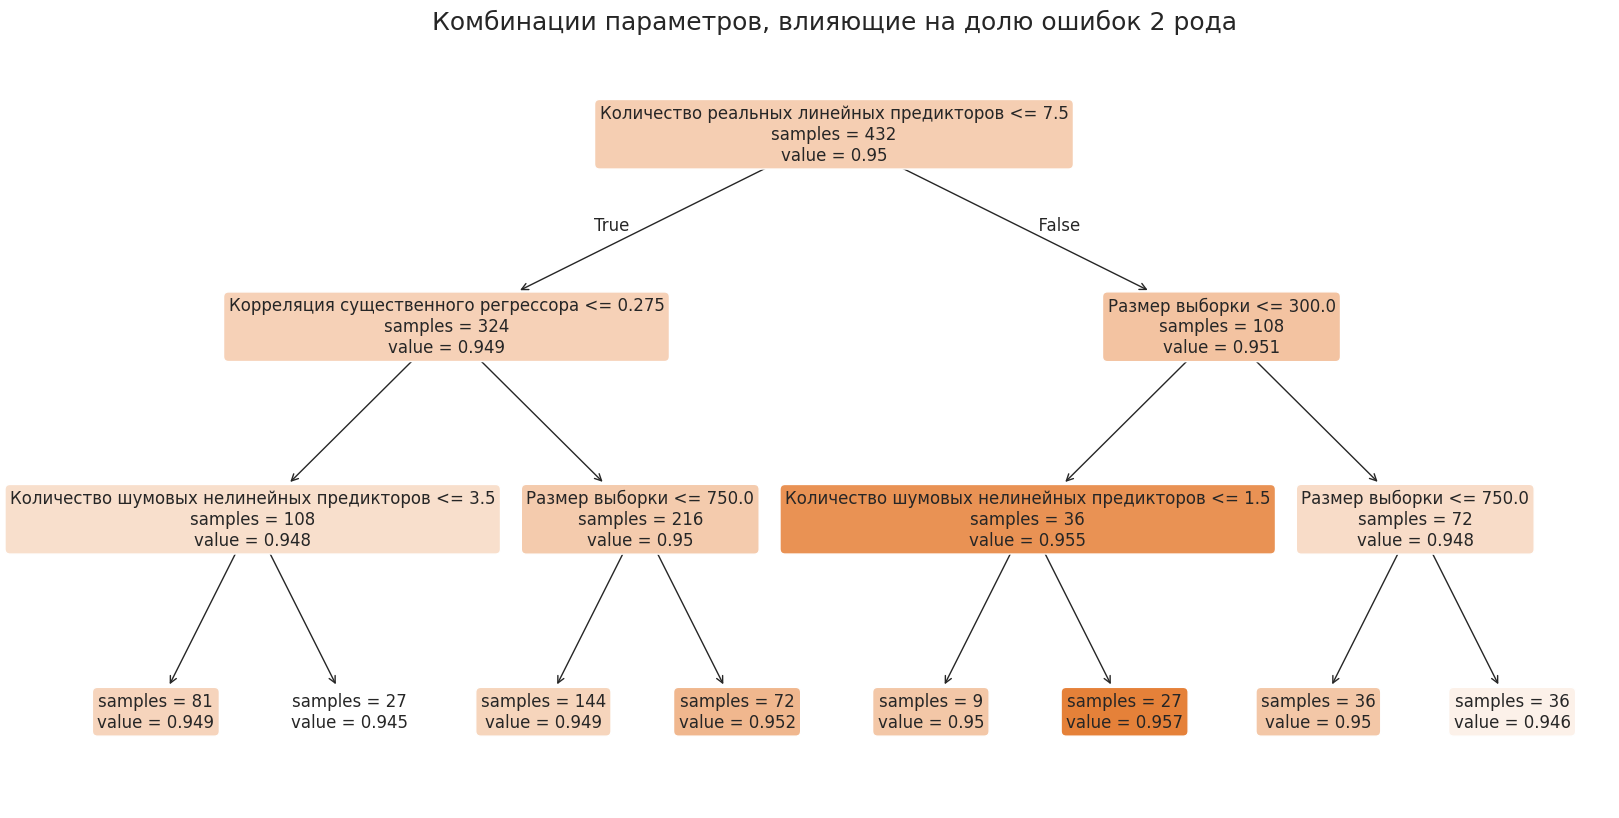

In [171]:
plot_decision_tree_thresholds(type_two_error_sig_regr_df, error_type='2')

In [172]:
type_two_error_sig_regr_df.to_csv('type_two_error_sig_regr_df.csv')

#### **Вывод**

Симуляции показали, что предположение RESET-теста о том, что любая ошибка спецификации порождает нелинейность, делает его склонным к совершению ошибок 2 рода при наличии линейной ошибки спецификации (линейный существенный регрессор)

### При комбинации всех трех типов искажений

In [174]:
sample_sizes = [500, 1000]
true_non_linear_terms_amounts = [0, 1, 2, 5]
feature_amounts = [5, 10]
added_features_amounts = [2, 3, 4]
significant_regressor_correlations = [0, 0.5, 0.9]
significant_regressor_effects = [0, 2, 5]
interactions = [0, 1, 2]

second_type_errors_all_factors = run_reset_test_simulation(1000, sample_sizes, true_non_linear_terms_amounts,
                                                  feature_amounts, added_features_amounts, interactions,
                                                  significant_regressor_correlations, significant_regressor_effects)

Streaming output truncated to the last 5000 lines.
Количество шумовых нелинейных предикторов: 3
Количество взаимодействий: 1
Корреляция существенного регрессора: 0
Влияние существенного регрессора: 2
Тип ошибки: 2
Доля ошибок: 0.03666666666666667
----------------------------------------------------------------------------------------------------
Симуляция №843
Размер выборки: 1000
Количество реальных нелинейных предикторов: 5
Количество реальных линейных предикторов: 5
Количество шумовых нелинейных предикторов: 3
Количество взаимодействий: 2
Корреляция существенного регрессора: 0
Влияние существенного регрессора: 2
Тип ошибки: 2
Доля ошибок: 0.05333333333333334
----------------------------------------------------------------------------------------------------
Симуляция №844
Размер выборки: 1000
Количество реальных нелинейных предикторов: 5
Количество реальных линейных предикторов: 5
Количество шумовых нелинейных предикторов: 3
Количество взаимодействий: 0
Корреляция существенного регр

In [175]:
type_two_error_all_factors_df = pd.DataFrame.from_dict(second_type_errors_all_factors, orient='index').set_index('Номер симуляции')

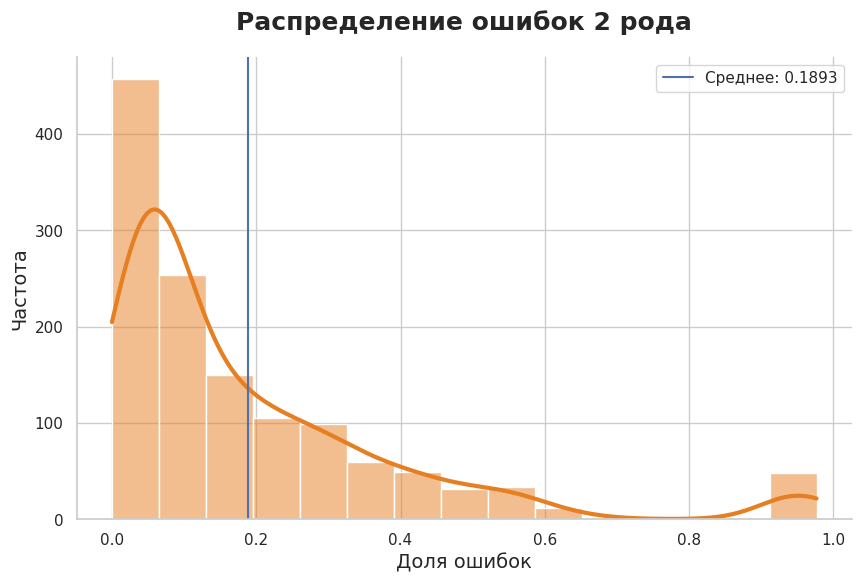

In [176]:
plot_errors_distribution(type_two_error_all_factors_df, error_type='2')

In [177]:
columns_to_drop = ['Тип ошибки', 'p-values']

corr = type_two_error_all_factors_df.drop(columns=columns_to_drop).corr().apply(lambda x: np.round(x, 4))

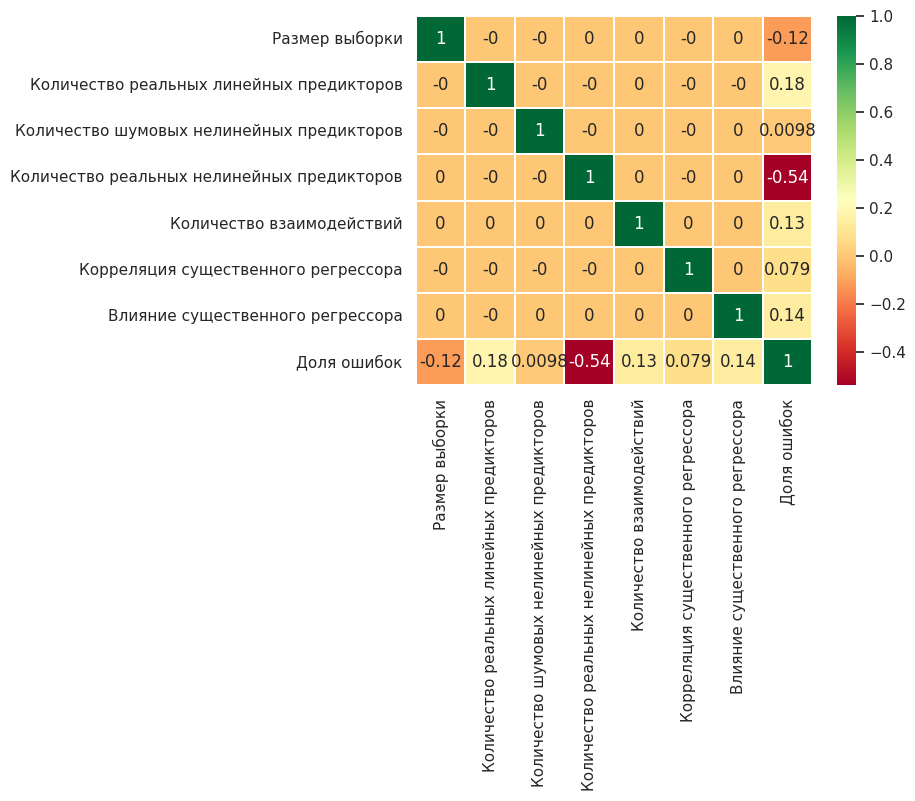

In [178]:
plt.title(f"Матрица корреляций между параметрами симуляции", fontsize=18, pad=20, fontweight='bold')

sns.heatmap(corr, cmap ='RdYlGn', linewidths = 0.30, annot = True)
plt.show()

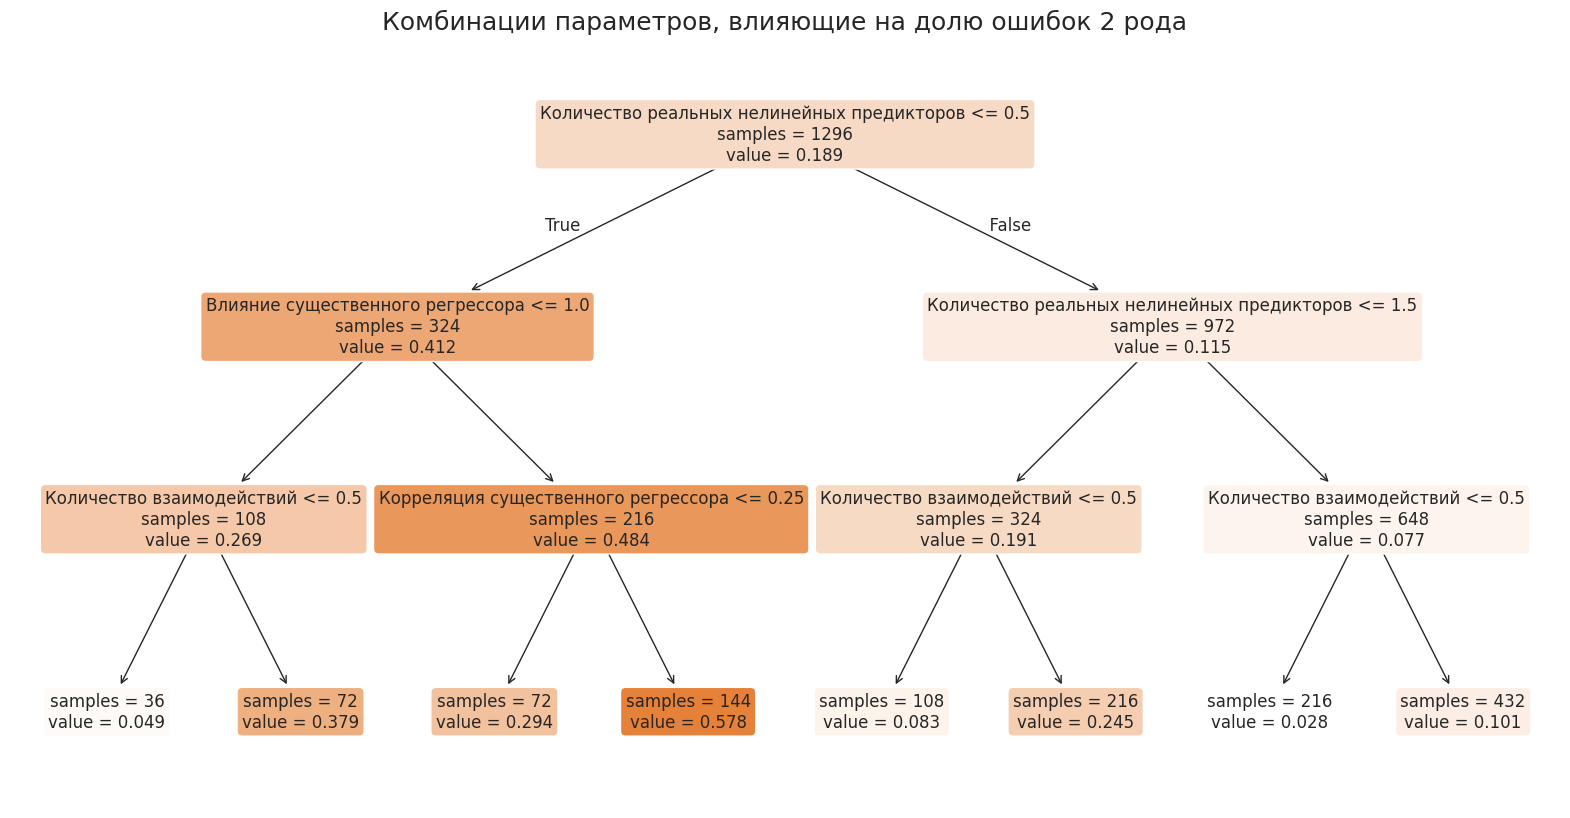

In [179]:
plot_decision_tree_thresholds(type_two_error_all_factors_df, error_type='2')

In [180]:
type_two_error_all_factors_df.to_csv('type_two_error_all_factors_df.csv')

# Применение на реальных данных